In [62]:
# Importing PyTorch
import torch

# Setting up device agnostic code
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print("Device:", device)

from torch import nn

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True

# Importing torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# Importing matplotlib for visualisation
import matplotlib.pyplot as plt

# Importing libraries for confusion matrices/heatmaps
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Checking versions
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

Device: cuda
PyTorch version: 2.9.0+cu126
torchvision version: 0.24.0+cu126


In [48]:
# Training data
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

# Testing data
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

# Creating dataloaders
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)
test_dataloader  = DataLoader(test_data, batch_size=32, shuffle=False)

In [40]:
# Defining model using for loop as stated in the question
class model_1(nn.Module):
    def __init__(self, input_size, hidden_layers, output_size):
        super().__init__()

        layers = []
        layers.append(nn.Flatten())
        prev = input_size

        for h in hidden_layers:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h

        layers.append(nn.Linear(prev, output_size))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [30]:
# Candidate models
models = {
    "shallow_1_64": model_1(input_size, [64], output_size).to(device),
    "shallow_1_128": model_1(input_size, [128], output_size).to(device),
    "deep_32_32": model_1(input_size, [32, 32], output_size).to(device),
    "deep_32_16_16": model_1(input_size, [32, 16, 16], output_size).to(device),
    "deep_16_16_16": model_1(input_size, [16, 16, 16], output_size).to(device),
    "wide_1_256": model_1(input_size, [256], output_size).to(device)
}

# Optimising using Adam instead
optimizers = {name: torch.optim.Adam(models[name].parameters(), lr=1e-3)
              for name in models.keys()}

In [5]:
input_size = 28 * 28 # 784
output_size = 10 # 10 clothing categories

In [12]:
from timeit import default_timer as timer

def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [18]:
# Defining loss
loss_fn = nn.CrossEntropyLoss()

In [13]:
# Defining accuracy
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [14]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):

    train_loss, train_acc = 0, 0
    model.to(device)

    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)

        # Forward pass
        y_pred = model(X)

        # Loss
        loss = loss_fn(y_pred, y)
        train_loss += loss

        # Accuracy
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train Loss: {train_loss:.5f} | Train Accuracy: {train_acc:.2f}%")
    return train_loss, train_acc

In [20]:
def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):

    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            # Forward pass
            test_pred = model(X)

            # Accumulating loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

    test_loss = test_loss / len(data_loader)
    test_acc = test_acc / len(data_loader)

    print(f"Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%\n")

    return test_loss, test_acc

In [49]:
epochs = 15
results = {}

for name in models.keys():
    print(f"\n==============================")
    print(f"Training model: {name}")
    print(f"==============================\n")

    model = models[name]
    optimizer = optimizers[name]

    # Initialising performance metrics
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []

    train_time_start = timer()

    # Looping over each epoch
    for epoch in range(epochs):
        print(f"Epoch: {epoch+1}\n--------")

        # Calculating training loss and accuracy
        train_loss, train_acc = train_step(
            model=model,
            data_loader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            accuracy_fn=accuracy_fn,
            device=device
        )

        # Next, calculating test loss and accuracy
        test_loss, test_acc = test_step(
            model=model,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device
        )

        train_losses.append(train_loss.item())
        train_accs.append(train_acc)
        test_losses.append(test_loss.item())
        test_accs.append(test_acc)

    train_time_end = timer()
    total_time = print_train_time(train_time_start, train_time_end,
                                  device=device)

    # Saving results for later plotting/analysis
    results[name] = {
        "train_loss": train_losses,
        "test_loss": test_losses,
        "train_acc": train_accs,
        "test_acc": test_accs,
        "time": total_time,
        "model": model
    }


Training model: shallow_1_64

Epoch: 1
--------
Train Loss: 0.15689 | Train Accuracy: 94.10%
Test Loss: 0.45814 | Test Accuracy: 87.37%

Epoch: 2
--------
Train Loss: 0.14680 | Train Accuracy: 94.50%
Test Loss: 0.47671 | Test Accuracy: 87.82%

Epoch: 3
--------
Train Loss: 0.14613 | Train Accuracy: 94.55%
Test Loss: 0.43348 | Test Accuracy: 88.13%

Epoch: 4
--------
Train Loss: 0.14322 | Train Accuracy: 94.67%
Test Loss: 0.45320 | Test Accuracy: 88.50%

Epoch: 5
--------
Train Loss: 0.14244 | Train Accuracy: 94.70%
Test Loss: 0.46301 | Test Accuracy: 88.05%

Epoch: 6
--------
Train Loss: 0.14224 | Train Accuracy: 94.74%
Test Loss: 0.45962 | Test Accuracy: 87.98%

Epoch: 7
--------
Train Loss: 0.14141 | Train Accuracy: 94.72%
Test Loss: 0.48740 | Test Accuracy: 87.87%

Epoch: 8
--------
Train Loss: 0.13776 | Train Accuracy: 94.89%
Test Loss: 0.47426 | Test Accuracy: 87.49%

Epoch: 9
--------
Train Loss: 0.13683 | Train Accuracy: 94.98%
Test Loss: 0.48692 | Test Accuracy: 87.64%

Epoch:

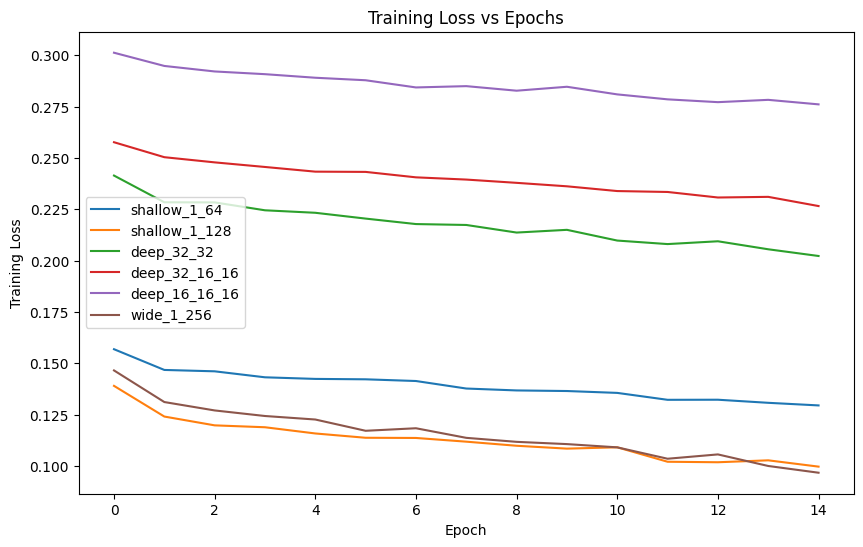

In [53]:
plt.figure(figsize=(10,6))

for name, data in results.items():
    plt.plot(data["train_loss"], label=f"{name}")

plt.title("Training Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.show()

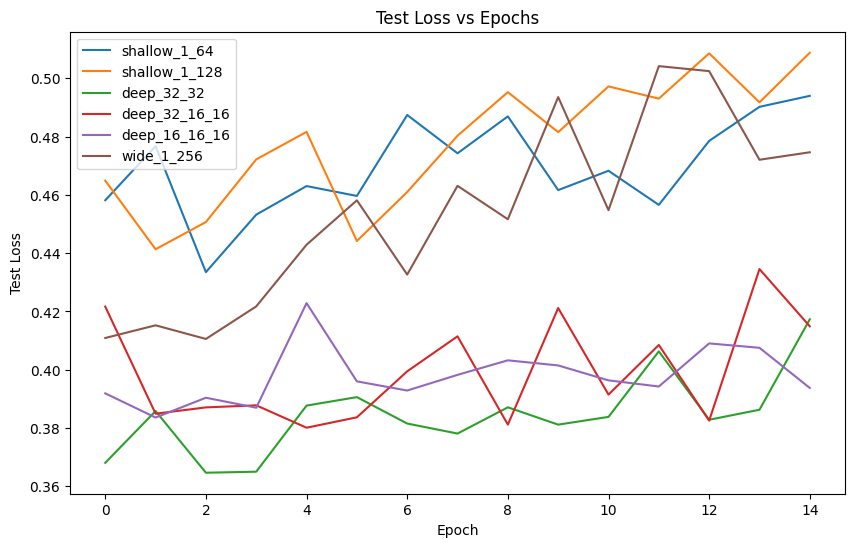

In [54]:
plt.figure(figsize=(10,6))

for name, data in results.items():
    plt.plot(data["test_loss"], label=f"{name}")

plt.title("Test Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.legend()
plt.show()

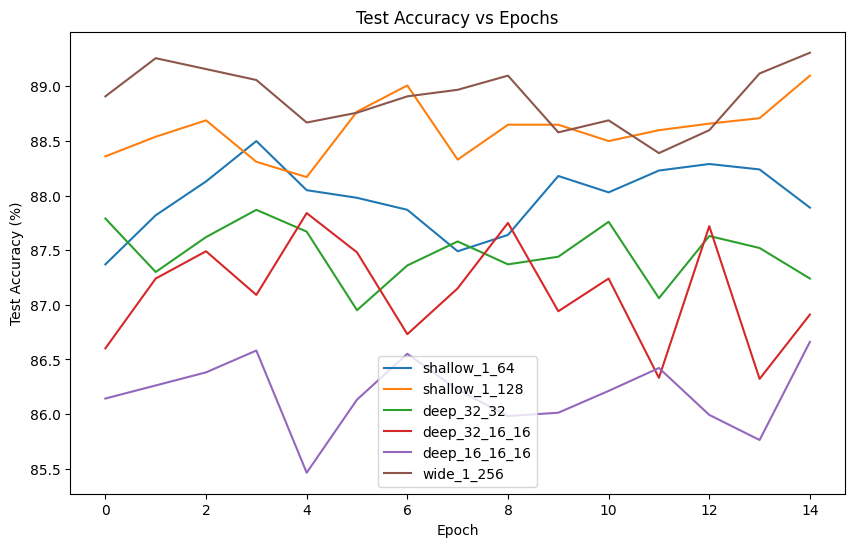

In [56]:
plt.figure(figsize=(10,6))

for name, data in results.items():
    plt.plot(data["test_acc"], label=f"{name}")

plt.title("Test Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.legend()
plt.show()

In [57]:
# Simple function to count parameters for all models
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

for name, m in models.items():
    print(name, count_params(m))

shallow_1_64 50890
shallow_1_128 101770
deep_32_32 26506
deep_32_16_16 26090
deep_16_16_16 13274
wide_1_256 203530


In [74]:
# Selecting chosen model
chosen_model = models["shallow_1_128"]

# Putting model in eval mode
chosen_model.eval()

# Choosing random test samples
import random
random.seed(42)

test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# Running predictions
pred_logits = []
with torch.inference_mode():
    for sample in test_samples:
        sample = sample.unsqueeze(0).to(device)
        logit = chosen_model(sample)
        pred_logits.append(logit.cpu())

pred_probs = torch.cat(pred_logits)
pred_classes = pred_probs.argmax(dim=1)

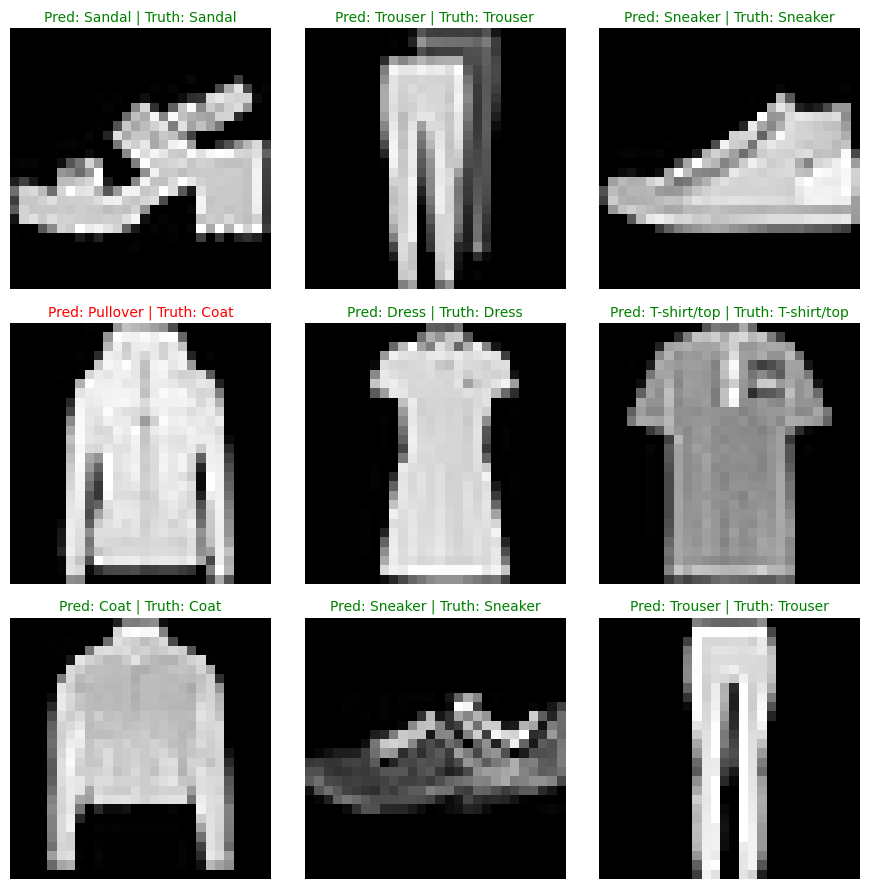

In [75]:
plt.figure(figsize=(9, 9))
rows, cols = 3, 3

for i, sample in enumerate(test_samples):
    plt.subplot(rows, cols, i + 1)

    plt.imshow(sample.squeeze(), cmap="gray")

    pred_label = class_names[pred_classes[i]]
    true_label = class_names[test_labels[i]]

    title = f"Pred: {pred_label} | Truth: {true_label}"

    if pred_label == true_label:
        plt.title(title, fontsize=10, color="green")
    else:
        plt.title(title, fontsize=10, color="red")

    plt.axis("off")

plt.tight_layout()
plt.show()

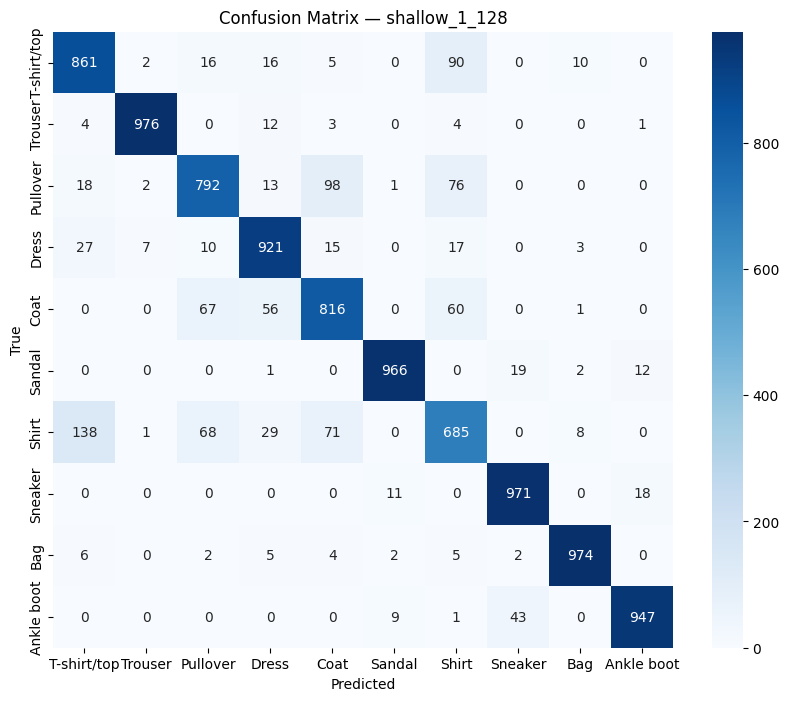

In [76]:
class_names = train_data.classes

# Confusion matrix and heatmap
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — shallow_1_128")
plt.show()